# 📊 Análisis de Facturación — Data Science desde 0
Notebook con el análisis exploratorio de la facturación de una pyme (datos anonimizados), como parte de la serie "Data Science desde 0".

## Setup
Importamos las librerías necesarias.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

## 1. Carga y limpieza de datos
Cargamos el excel y preparamos los datos: conversión de fechas y eliminación de filas incompletas.

In [2]:
df = pd.read_excel('balance oficialAA.xlsx', sheet_name='FACTURADO-BASE DE DATOS ')

In [3]:
df.head()

,NOMBRE DE CLIENTE,VTO DEL PAGO,GRUPO,TIPO DE COBRO,MES,FECHA DE FACTURACCION,FECHA DE PAGO,INTERES,SERVICIO,MONTO USD,MONTO AR,COTIZACION DOLAR,FORMA DE PAGO,FACTURA O BOLETA,N° BOLETA O FACTURA,FORMA DE PAGO (PROGRAMACION),Nº CUOTAS (PROGRAMACION),TOTAL A PAGAR USD (PROGRAMACION)
0,Distribuidora Del Sol,NaT,NaN,NaN,2024-01-01,NaT,NaT,NaN,NaN,NaN,0.0,1186.0,NaN,NaN,NaN,NaN,NaN,NaN
1,Mercado Central SRL,NaT,REDES B,ADELANTADO,2024-01-01,2024-01-27,NaT,NaN,REDES,170.000000,201620.0,NaN,NaN,FACTURA,NaN,NaN,NaN,NaN
2,Servicios San Martín,NaT,REDES B,NaN,2024-01-01,2024-01-27,NaT,NaN,REDES,170.000000,201620.0,NaN,NaN,BOLETA,NaN,NaN,NaN,NaN
3,Ferretería El Calafate,NaT,REDES B,VENCIDO,2024-01-01,2024-01-27,NaT,NaN,REDES,252.951096,300000.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,Comercial La Paz,NaT,REDES B,VENCIDO,2024-01-01,2024-01-27,NaT,NaN,REDES,101.180438,120000.0,NaN,NaN,BOLETA,NaN,NaN,NaN,NaN


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 337 entries, 0 to 336
Data columns (total 18 columns):
 #   Column                            Non-Null Count  Dtype         
---  ------                            --------------  -----         
 0   NOMBRE DE CLIENTE                 337 non-null    object        
 1   VTO DEL PAGO                      92 non-null     datetime64[ns]
 2   GRUPO                             322 non-null    object        
 3   TIPO DE COBRO                     307 non-null    object        
 4   MES                               337 non-null    datetime64[ns]
 5   FECHA DE FACTURACCION             318 non-null    datetime64[ns]
 6   FECHA DE PAGO                     220 non-null    datetime64[ns]
 7   INTERES                           15 non-null     float64       
 8   SERVICIO                          322 non-null    object        
 9   MONTO USD                         322 non-null    float64       
 10  MONTO AR                          325 non-null    

In [5]:
# 3. Conversión de la columna a formato fecha
df['FECHA DE FACTURACCION '] = pd.to_datetime(df['FECHA DE FACTURACCION '], dayfirst=True)

In [6]:
# 4. Limpieza de filas vacías (dropna usando el subset en las columnas clave)
df = df.dropna(subset=['FECHA DE FACTURACCION ', 'MONTO USD'])


In [7]:
# 5. Revisión final para confirmar que se limpió todo bien
print("\n--- INFO DESPUÉS DE LA LIMPIEZA ---")
df.info()


--- INFO DESPUÉS DE LA LIMPIEZA ---
<class 'pandas.core.frame.DataFrame'>
Index: 318 entries, 1 to 336
Data columns (total 18 columns):
 #   Column                            Non-Null Count  Dtype         
---  ------                            --------------  -----         
 0   NOMBRE DE CLIENTE                 318 non-null    object        
 1   VTO DEL PAGO                      92 non-null     datetime64[ns]
 2   GRUPO                             318 non-null    object        
 3   TIPO DE COBRO                     304 non-null    object        
 4   MES                               318 non-null    datetime64[ns]
 5   FECHA DE FACTURACCION             318 non-null    datetime64[ns]
 6   FECHA DE PAGO                     217 non-null    datetime64[ns]
 7   INTERES                           13 non-null     float64       
 8   SERVICIO                          318 non-null    object        
 9   MONTO USD                         318 non-null    float64       
 10  MONTO AR          

## 2. Evolución mensual de facturación
¿El negocio está creciendo o estancado? Agrupamos la facturación por mes para ver la tendencia.

In [8]:
df['MES_PERIODO'] = df['FECHA DE FACTURACCION '].dt.to_period('M')

facturacion_mensual = df.groupby('MES_PERIODO')['MONTO USD'].sum().astype(int)

In [9]:
print(facturacion_mensual)

MES_PERIODO
2024-01    2487
2024-02    4740
2024-03    3854
2024-04    4112
2024-05    5196
2024-06    5909
2024-07    7721
2024-08    9242
2024-09    7365
2024-10    9287
2024-11    8129
2024-12    8584
Freq: M, Name: MONTO USD, dtype: int64


In [10]:
facturacion_mensual.index = facturacion_mensual.index.to_timestamp()


In [11]:
plt.figure(figsize=(25, 5))

<Figure size 2500x500 with 0 Axes>

<Figure size 2500x500 with 0 Axes>

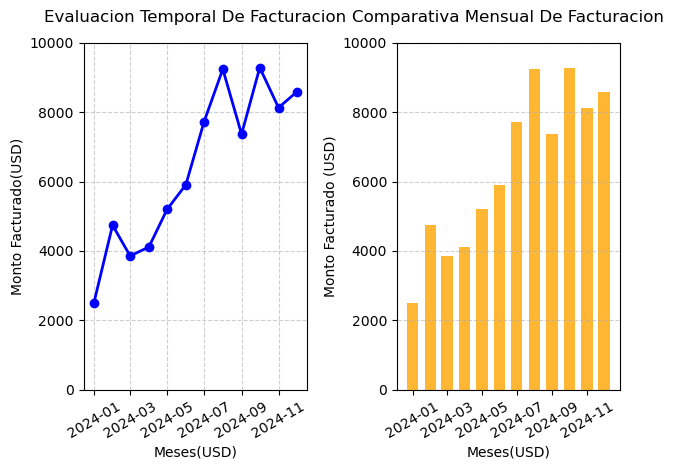

In [12]:
# --- GRÁFICO 1: Líneas (Izquierda) ---
# Creamos el primer sub-gráfico (1 fila, 2 columnas, posición 1)
plt.subplot(1, 2, 1)
plt.plot(facturacion_mensual.index, facturacion_mensual.values,  marker='o', color='blue', linewidth=2)
plt.title('Evaluacion Temporal De Facturacion', pad=15)
plt.xlabel('Meses(USD)')
plt.ylabel('Monto Facturado(USD)')
plt.grid(True, linestyle='--', alpha=0.6)
plt.xticks(rotation=30)
plt.ylim(0, 10000) 
# --- GRÁFICO 2: Barras (Derecha) ---
# Creamos el segundo sub-gráfico (1 fila, 2 columnas, posición 2)
plt.subplot(1, 2, 2)
plt.bar(facturacion_mensual.index, facturacion_mensual.values, color='orange', width=20, alpha=0.8)
plt.title('Comparativa Mensual De Facturacion', pad=15)
plt.xlabel('Meses(USD)')
plt.ylabel('Monto Facturado (USD)')
plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.xticks(rotation=30)
plt.ylim(0, 10000)

# Ajustar el diseño para que no se superpongan las etiquetas
plt.subplots_adjust(wspace=0.3)
plt.tight_layout()
#  Mostrar los gráficos en pantalla
plt.savefig('graficos_facturacion.png', dpi=300, bbox_inches='tight')
plt.show()

### Variación porcentual mes a mes
Calculamos qué mes tuvo la mayor caída y la mayor suba en la facturación.

In [13]:
variacion = facturacion_mensual.pct_change() * 100

In [14]:
mes_peor = variacion.idxmin()
caida_max = variacion.min()
print(f"La mayor caída fue en {mes_peor} con un {caida_max:.2f}%")

La mayor caída fue en 2024-09-01 00:00:00 con un -20.31%


In [15]:
mes_mejor = variacion.idxmax()
suba_max =  variacion.max()
print(f"La mayor suba fue en {mes_mejor} con un {suba_max:.2f}%")

La mayor suba fue en 2024-02-01 00:00:00 con un 90.59%


## 3. Top 5 clientes por facturación
¿Quiénes son los clientes que más facturan? Limpiamos los nombres y agrupamos por cliente.

In [16]:
df['CLIENTE_LIMPIO'] = df['NOMBRE DE CLIENTE'].str.strip().str.upper()

In [17]:
top_5_clientes = (
    df.groupby('CLIENTE_LIMPIO')['MONTO USD']
    .sum()
    .sort_values(ascending=False)
    .head(5)
    .astype(int)
)
print(top_5_clientes)
                 

CLIENTE_LIMPIO
CONSTRUCTORA DEL NORTE    9246
LUMINEX SERVICIOS         6561
BLOQUE SUR SRL            6310
TEXTILES AURORA           5236
PANADERÍA EL TRIGAL       4827
Name: MONTO USD, dtype: int64


### Concentración de clientes
¿Qué tan dependiente es el negocio de sus principales clientes?

In [18]:
porcentaje_concentracion = (top_5_clientes.sum() / df['MONTO USD'].sum()) * 100

In [19]:
print(
    f'El Top 5 de clientes representa el {porcentaje_concentracion:.2f}% de la facturación total.'
)

El Top 5 de clientes representa el 41.99% de la facturación total.


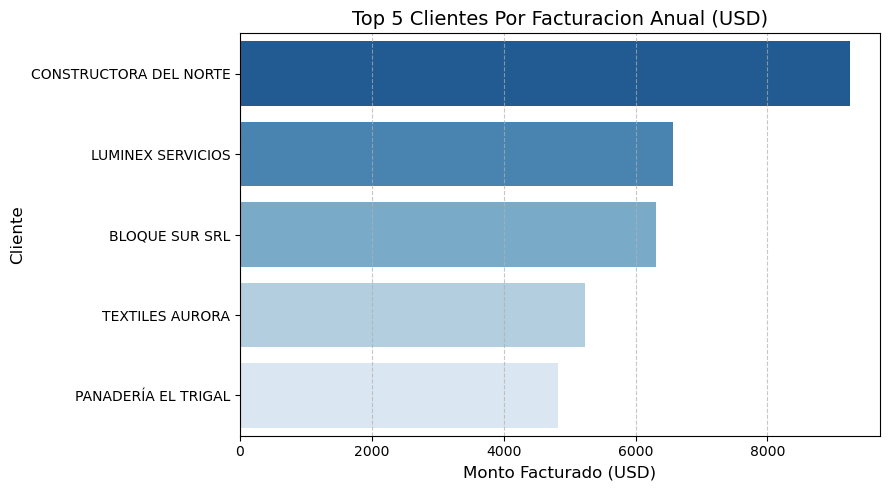

In [20]:
plt.figure(figsize=(9, 5))
sns.barplot(
    x=top_5_clientes.values,
    y=top_5_clientes.index,
    hue=top_5_clientes.index,
    palette='Blues_r',
    legend=False,
)
plt.title('Top 5 Clientes Por Facturacion Anual (USD)', fontsize=14)
plt.xlabel('Monto Facturado (USD)', fontsize=12)
plt.ylabel('Cliente', fontsize=12)
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()


## 4. Morosidad
Analizamos cuánto tardan los clientes en pagar: tanto las facturas ya cobradas como las pendientes.

In [21]:
# 1. Filtramos las filas donde 'FECHA DE PAGO' NO es nula (.notna())
df_cobradas = df[df['FECHA DE PAGO'].notna()].copy()


In [22]:
# 2. Restamos la fecha real de pago menos el vencimiento
# Usamos .dt.days para convertir la diferencia de fechas a un número entero de días
df_cobradas['dias_atraso'] = (
    df_cobradas['FECHA DE PAGO'] - df_cobradas['VTO DEL PAGO']
).dt.days

In [23]:
# 3. Calculamos el promedio de días de demora
promedio_atraso = df_cobradas['dias_atraso'].mean()
print(f'Promedio de días de atraso en facturas cobradas: {promedio_atraso:.1f} días')
# el resultado  de esto, quiere decir que el cliente paga -0.5 dias, esto queire decir que el cliente paga medio dia antes de la fecha de vencimiento, en conclusion el cliente que paga es muy cumplidor.

Promedio de días de atraso en facturas cobradas: -0.5 días


In [24]:
#Filtramos donde 'FECHA DE PAGO' SÍ es nula (.isna())
df_pendientes = df[df['FECHA DE PAGO'].isna()].copy()

In [25]:
# Restamos la fecha de hoy (pd.Timestamp.today()) menos la fecha de vencimiento
df_pendientes['dias_vencido'] = (
    pd.Timestamp.today() - df_pendientes['VTO DEL PAGO']
).dt.days

In [26]:
# Calculamos el promedio de días que llevan vencidas estas facturas impagas
promedio_vencido = df_pendientes['dias_vencido'].mean()
print(
    f'Promedio de días vencidas de la deuda pendiente: {promedio_vencido:.1f} días'
)
# todas esas facturas que quedaron en el Excel sin fecha de pago son deuda incobrable o incobrables históricas (tienen casi dos años de mora), no facturas que vencieron "semana pasada".

Promedio de días vencidas de la deuda pendiente: 713.0 días


## 5. Forma de pago
¿Qué medio de pago predomina, y hay diferencias entre clientes grandes y chicos?

In [27]:
print('---Frecuencia Forma De Pago---')
print(df['FORMA DE PAGO'].value_counts())
print('\n' + '=' * 40 + '\n')

---Frecuencia Forma De Pago---
FORMA DE PAGO
TRANFERENCIA    158
EFECTIVO         96
CHEQUE           22
Name: count, dtype: int64




In [28]:
# 1. Creamos primero la columna CLIENTE_LIMPIO para que exista en el df
df['CLIENTE_LIMPIO'] = df['NOMBRE DE CLIENTE'].str.strip().str.upper()

# 2. Crear la columna TIPO_CLIENTE (Grande vs Chico)
df['TIPO_CLIENTE'] = np.where(
    df['CLIENTE_LIMPIO'].isin(top_5_clientes.index), 'Grande', 'Chico'
)

# 3. Cruzar ambas variables con pd.crosstab
tabla_cruzada = pd.crosstab(df['TIPO_CLIENTE'],df['FORMA DE PAGO'] )

print('--- Comportamiento de Pago por Tipo de Cliente ---')
print(tabla_cruzada)

--- Comportamiento de Pago por Tipo de Cliente ---
FORMA DE PAGO  CHEQUE  EFECTIVO  TRANFERENCIA
TIPO_CLIENTE                                 
Chico               1        84           118
Grande             21        12            40


## 6. Estacionalidad por cliente
Cruzamos el Top 5 de clientes con la evolución mensual para ver patrones estacionales.

In [29]:
# 1. Filtrar solo los datos del Top 5 de clientes
df_top5 = df[df['CLIENTE_LIMPIO'].isin(top_5_clientes.index)]

In [30]:
evolucion_top5 = (
    df_top5.groupby(['MES', 'CLIENTE_LIMPIO'])['MONTO USD'].sum().unstack()
)

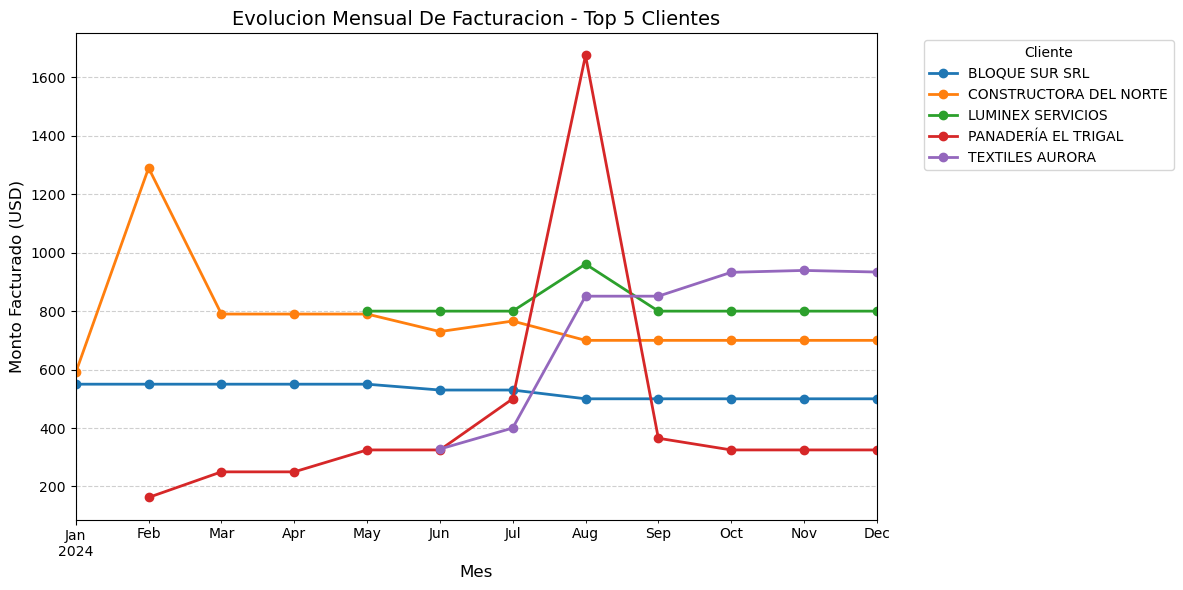

In [31]:
# 4. Graficar la evolución mensual
ax = evolucion_top5.plot(figsize=(12, 6), marker='o', linewidth=2)
plt.title('Evolucion Mensual De Facturacion - Top 5 Clientes', fontsize=14)
plt.xlabel('Mes', fontsize=12)
plt.ylabel('Monto Facturado (USD)', fontsize=12)
plt.legend(title='Cliente', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True, linestyle='--', alpha=0.6)

plt.tight_layout()
plt.show()